# On the Spot

In [1]:
import numpy as np

In [2]:
from sklearn.datasets import make_moons

In [3]:
df= make_moons(n_samples= 1200, noise=0.1)

In [4]:
print(df)

(array([[ 1.10220459,  0.07792759],
       [-0.92713026, -0.0059043 ],
       [ 0.9675537 ,  0.50465325],
       ...,
       [-0.56759859,  0.79236544],
       [ 0.89020026,  0.39572541],
       [ 1.03822889,  0.03970277]], shape=(1200, 2)), array([0, 0, 0, ..., 0, 0, 0], shape=(1200,)))


In [5]:
X= df[0]
y= df[1]

In [10]:
print(X, X.shape)

[[ 1.10220459  0.07792759]
 [-0.92713026 -0.0059043 ]
 [ 0.9675537   0.50465325]
 ...
 [-0.56759859  0.79236544]
 [ 0.89020026  0.39572541]
 [ 1.03822889  0.03970277]] (1200, 2)


In [11]:
print(y, y.shape)

[0 0 0 ... 0 0 0] (1200,)


In [71]:
class NeuronNetwork:
    def __init__(self, lr= 0.001, epochs= 100):
        self.lr= lr
        self.epochs= epochs

    def relu(self, z):
        return np.maximum(0, z)
    
    def sigmoid(self, z):
        return 1/(1 + np.log(-z))
    
    def d_relu(self, z):
        return 1 if z>0 else 0
    
    def d_sigmoid(self, z):
        return self.sigmoid(z)*(1 - self.sigmoid(z))
    
    def training(self, X, y):
        store= []
        self.W1 = np.random.randn(2,12)*0.1
        self.b1 = np.zeros((1,12))
        self.W2 = np.random.randn(12,1)*0.1
        self.b2 = np.zeros((1,1))

        y_h= np.ones((X.shape[0], 1))
        for _ in range(self.epochs):
            y_h= self.forward(X)
            self.L = self.BCE(y, y_h) 
            W1_n, W2_n, b1_n, b2_n = self.backward(X, y, 'SGD')
            store.append([W1_n, W2_n, b1_n, b2_n])
        return                
            

    def forward(self, X):
        self.Z1= np.dot(X, self.W1) + self.b1
        self.A1= self.relu(self.Z1)
        self.Z1= np.dot(self.A1, self.W2) + self.b2
        self.A2= self.sigmoid(self.Z1)
        return self.A2
    
    def backward(self, X, y, op= "None"):
        m= X.shape[0]
        dZ2= self.A2 - y
        dW2= self.A2.T @ dZ2 / m
        db2= np.sum(dZ2, axis= 0, keepdims= True)
        dA1= dZ2 @ self.W2.T
        dZ1= dA1 * self.d_sigmoid(self.Z1)
        dW1= self.X.T @ self.Z2 / m
        db1= np.sum(dZ1, axis= 0, keepdims= True)
        
        # return self.optimizers(op)

        self.W1 -= self.lr * dW1
        self.W2 -= self.lr * dW2
        self.b1 -= self.lr * db1
        self.b2 -= self.lr * db2
        return self.W1, self.W2, self.b1, self.b2
    
    def optimizers(self, op):
        params= [self.W1, self.W2, self.b1, self.b2]
        grads= [self.dW1, self.dW2, self.db1, self.db2]

        if self.op == "SGD":
            for k in self.params:
                self.params[k] -= self.lr * self.grads[k]

        if self.op == "Momentum":
            beta= 0.9
            v={k:0 for k in self.params}
            for k in self.params:
                v[k]= beta*v[k] - self.lr*self.grads[k]
                self.params[k]+= v[k]
        
        if self.op == "Adam":
            beta= 0.9
            v={k:0 for k in self.params}
            m= v[0]
            for k in self.params:
                v[k]-= beta*v[k] - self.lr*self.grads[k]
                m= beta*m + self.lr*self.grads[k]

                self.params[k] -= self.lr * m *self.grads[k] / np.sqrt(v[k] + 1e-6)
        return params
    
    def BCE(self, y_h, y):
        return -((1-y_h)*np.log(y) + y*np.log(1 - y_h))
    

In [12]:
v= np.ones((X.shape[0], 1))

In [14]:
print(v.shape)

(1200, 1)


In [13]:
print(v)

[[1.]
 [1.]
 [1.]
 ...
 [1.]
 [1.]
 [1.]]


In [68]:
NN= NeuronNetwork()

In [72]:
print(NN.W1.shape)

(2, 12)


In [74]:
print(NN.W1, NN.W2, NN.b1, NN.b2)

[[ 0.26685141 -0.04977072  0.02005524  0.0084845  -0.029046   -0.15792776
  -0.13481233 -0.12233704  0.06238434 -0.11556249 -0.02499538 -0.05976052]
 [-0.17353903  0.11460955 -0.1545461   0.20475684  0.3095205   0.02197496
  -0.09209093 -0.0142945   0.01040855 -0.01850486 -0.10598965  0.16980404]] [[ 0.11674362]
 [-0.0777163 ]
 [ 0.00937734]
 [ 0.1790856 ]
 [-0.20790228]
 [-0.02224624]
 [ 0.02818563]
 [ 0.03458319]
 [-0.08153715]
 [ 0.10258272]
 [-0.11809581]
 [ 0.03427879]] [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] [[0.]]


In [76]:
import matplotlib.pyplot as plt

In [ ]:
plt.

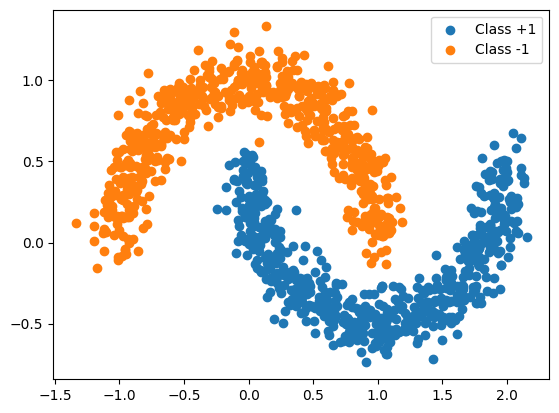

In [82]:
x1v = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)


plt.scatter(X[y==1][:,0], X[y==1][:,1], label='Class +1')
plt.scatter(X[y==0][:,0], X[y==0][:,1], label='Class -1')
plt.legend(); plt.show()

In [73]:
NN.training(np.array(X), np.array(y))

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19088\1618687805.py:10: RuntimeWarning: invalid value encountered in log
  return 1/(1 + np.log(-z))
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19088\1618687805.py:86: RuntimeWarning: invalid value encountered in log
  return -((1-y_h)*np.log(y) + y*np.log(1 - y_h))
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19088\1618687805.py:86: RuntimeWarning: divide by zero encountered in log
  return -((1-y_h)*np.log(y) + y*np.log(1 - y_h))


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 1200)